# Rainfall Variational Autoencoder

This notebook implements a VAE for seasonal rainfall patterns, enabling:

1. **Latent space learning** - Discover underlying factors controlling rainfall patterns
2. **Season interpolation** - Generate intermediate climate scenarios
3. **Synthetic data generation** - Create unlimited training scenarios for RL
4. **Climate shift simulation** - Explore future climate scenarios

**Architecture:**

- Input: 150-day seasonal rainfall sequence
- Encoder: Conv1D → Latent space (μ, σ)
- Decoder: Latent → Conv1DTranspose → Rainfall sequence


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_PROCESSED = Path('../data/processed')
MODELS_DIR = Path('../models')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cpu


In [3]:
df = pd.read_csv(DATA_PROCESSED / 'combined_rainfall_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Region', 'Date']).reset_index(drop=True)

print(f"Loaded {len(df):,} records")
print(f"Regions: {sorted(df['Region'].unique())}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")

Loaded 67,570 records
Regions: ['Region1', 'Region2', 'Region3', 'Region4', 'Region5']
Years: 1983 - 2019


In [4]:
def extract_seasons(df, start_doy=60, season_length=150):
    """
    Extract seasonal rainfall sequences.
    
    Args:
        df: DataFrame with rainfall data
        start_doy: Day of year to start season (60 = March 1)
        season_length: Number of days in season
    
    Returns:
        List of (season_array, metadata) tuples
    """
    seasons = []
    metadata = []
    
    for region in df['Region'].unique():
        region_df = df[df['Region'] == region].copy()
        
        for year in region_df['Year'].unique():
            year_df = region_df[region_df['Year'] == year].copy()
            year_df['DOY'] = year_df['Date'].dt.dayofyear
            
            # Extract season window
            end_doy = start_doy + season_length
            season_df = year_df[(year_df['DOY'] >= start_doy) & (year_df['DOY'] < end_doy)]
            
            if len(season_df) >= season_length * 0.9:  # Allow 10% missing
                rainfall = season_df['Mean'].values[:season_length]
                
                # Pad if slightly short
                if len(rainfall) < season_length:
                    rainfall = np.pad(rainfall, (0, season_length - len(rainfall)), 
                                    mode='constant', constant_values=0)
                
                seasons.append(rainfall)
                metadata.append({
                    'region': region,
                    'year': year,
                    'total_rainfall': rainfall.sum(),
                    'rainy_days': (rainfall > 1).sum()
                })
    
    return np.array(seasons), pd.DataFrame(metadata)

# Extract seasons
SEASON_LENGTH = 150
seasons, metadata = extract_seasons(df, start_doy=60, season_length=SEASON_LENGTH)

print(f"Extracted {len(seasons)} seasons")
print(f"Season shape: {seasons.shape}")
print(f"\nTotal rainfall range: {metadata['total_rainfall'].min():.0f} - {metadata['total_rainfall'].max():.0f} mm")
print(f"Mean: {metadata['total_rainfall'].mean():.0f} mm")

Extracted 185 seasons
Season shape: (185, 150)

Total rainfall range: 245 - 761 mm
Mean: 534 mm


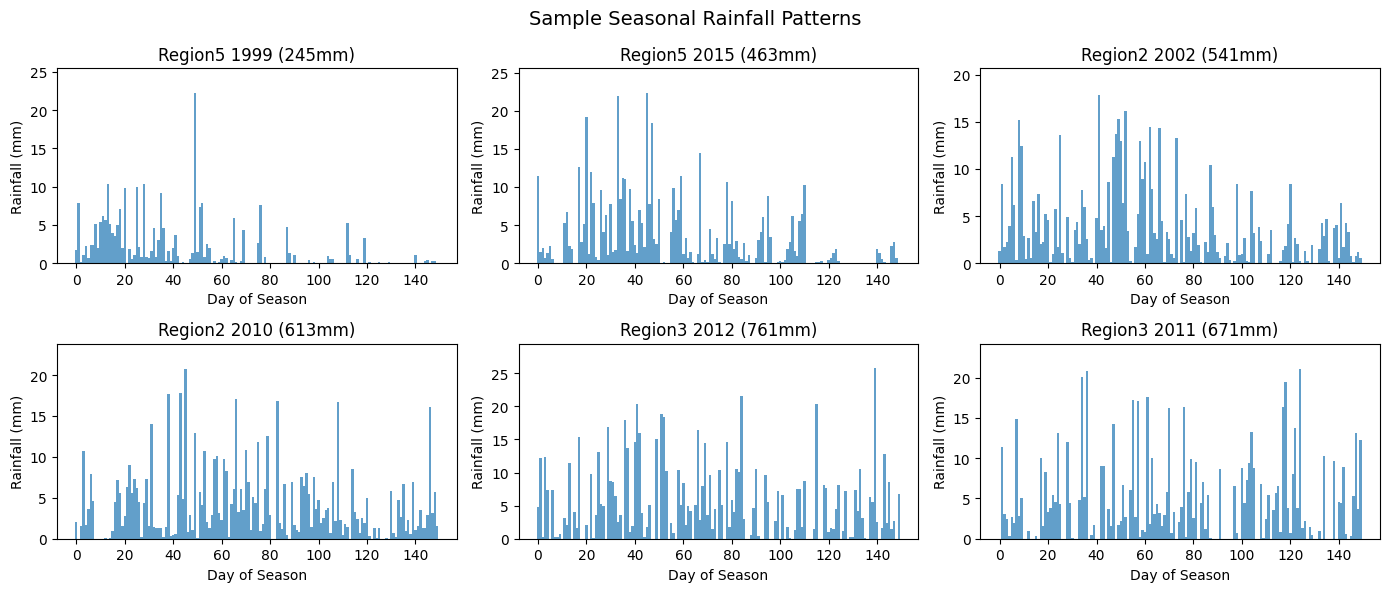

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

# Sort by total rainfall to show variety
sorted_idx = np.argsort(metadata['total_rainfall'].values)
examples = [sorted_idx[0], sorted_idx[len(sorted_idx)//4], sorted_idx[len(sorted_idx)//2],
            sorted_idx[3*len(sorted_idx)//4], sorted_idx[-1], np.random.choice(len(seasons))]

for ax, idx in zip(axes.flat, examples):
    ax.bar(range(SEASON_LENGTH), seasons[idx], alpha=0.7, width=1.0)
    meta = metadata.iloc[idx]
    ax.set_title(f"{meta['region']} {meta['year']} ({meta['total_rainfall']:.0f}mm)")
    ax.set_xlabel('Day of Season')
    ax.set_ylabel('Rainfall (mm)')
    ax.set_ylim(0, max(seasons[idx]) * 1.1 + 1)

plt.suptitle('Sample Seasonal Rainfall Patterns', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
seasons_log = np.log1p(seasons)  # log(1 + x) to handle zeros

# Scale to [0, 1] range for VAE
seasons_min = seasons_log.min()
seasons_max = seasons_log.max()
seasons_normalized = (seasons_log - seasons_min) / (seasons_max - seasons_min)

print(f"Original range: {seasons.min():.2f} - {seasons.max():.2f}")
print(f"Log range: {seasons_log.min():.2f} - {seasons_log.max():.2f}")
print(f"Normalized range: {seasons_normalized.min():.2f} - {seasons_normalized.max():.2f}")

norm_params = {'min': seasons_min, 'max': seasons_max}

def denormalize(x_norm):
    """Convert normalized VAE output back to rainfall."""
    x_log = x_norm * (seasons_max - seasons_min) + seasons_min
    return np.expm1(x_log)  # exp(x) - 1, inverse of log1p

Original range: 0.00 - 37.38
Log range: 0.00 - 3.65
Normalized range: 0.00 - 1.00


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(seasons_normalized, test_size=0.2, random_state=SEED)

X_train_t = torch.FloatTensor(X_train).unsqueeze(1)  # (N, 1, 150) for Conv1D
X_val_t = torch.FloatTensor(X_val).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t), batch_size=16, shuffle=False)

print(f"Train: {len(X_train)} seasons")
print(f"Val: {len(X_val)} seasons")
print(f"Tensor shape: {X_train_t.shape}")

Train: 148 seasons
Val: 37 seasons
Tensor shape: torch.Size([148, 1, 150])


In [ ]:
class RainfallEncoder(nn.Module):
    """Encode seasonal rainfall to latent space."""
    
    def __init__(self, seq_length=150, latent_dim=8):
        super().__init__()
        
        # Conv1D layers to extract patterns
        self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3)  # 150 -> 75
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)  # 75 -> 38
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)  # 38 -> 19
        
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)
        
        # Calculate flattened size: 128 * 19 = 2432
        self.flat_size = 128 * 19
        
        # Latent space projections
        self.fc_mu = nn.Linear(self.flat_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_size, latent_dim)
        
    def forward(self, x):
        # x: (batch, 1, 150)
        h = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        h = F.leaky_relu(self.bn2(self.conv2(h)), 0.2)
        h = F.leaky_relu(self.bn3(self.conv3(h)), 0.2)
        
        h = h.view(h.size(0), -1)  # Flatten
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        return mu, logvar


class RainfallDecoder(nn.Module):
    """Decode latent space to seasonal rainfall."""
    
    def __init__(self, seq_length=150, latent_dim=8):
        super().__init__()
        
        self.seq_length = seq_length
        self.flat_size = 128 * 19
        
        # Project latent to conv shape
        self.fc = nn.Linear(latent_dim, self.flat_size)
        
        # Transposed conv layers to upsample
        self.deconv1 = nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1)  # 19 -> 38
        self.deconv2 = nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=0)  # 38 -> 75
        self.deconv3 = nn.ConvTranspose1d(32, 1, kernel_size=7, stride=2, padding=3, output_padding=1)  # 75 -> 150
        
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(32)
        
    def forward(self, z):
        # z: (batch, latent_dim)
        h = self.fc(z)
        h = h.view(h.size(0), 128, 19)
        
        h = F.leaky_relu(self.bn1(self.deconv1(h)), 0.2)
        h = F.leaky_relu(self.bn2(self.deconv2(h)), 0.2)
        h = torch.sigmoid(self.deconv3(h))  # Output in [0, 1]
        
        # Ensure exact output size
        if h.size(2) != self.seq_length:
            h = F.interpolate(h, size=self.seq_length, mode='linear', align_corners=False)
        
        return h


class RainfallVAE(nn.Module):
    """Variational Autoencoder for seasonal rainfall patterns."""
    
    def __init__(self, seq_length=150, latent_dim=8):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.encoder = RainfallEncoder(seq_length, latent_dim)
        self.decoder = RainfallDecoder(seq_length, latent_dim)
        
    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = μ + ε * σ"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar
    
    def encode(self, x):
        """Encode to latent space (returns mean)."""
        mu, _ = self.encoder(x)
        return mu
    
    def decode(self, z):
        """Decode from latent space."""
        return self.decoder(z)
    
    def sample(self, n_samples=1):
        """Generate random samples from prior."""
        z = torch.randn(n_samples, self.latent_dim).to(next(self.parameters()).device)
        return self.decode(z)

LATENT_DIM = 8  # Compact representation of season
model = RainfallVAE(seq_length=SEASON_LENGTH, latent_dim=LATENT_DIM).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Latent dimension: {LATENT_DIM}")

Model parameters: 164,625
Latent dimension: 8


In [24]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    VAE loss = Reconstruction + β * KL divergence
    
    Using MSE for reconstruction (rainfall values, not binary)
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence: -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [25]:
def train_vae(model, train_loader, val_loader, epochs=100, lr=1e-3, beta=1.0):
    """Train VAE with annealed KL weight."""
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    history = {'train_loss': [], 'val_loss': [], 'recon_loss': [], 'kl_loss': []}
    
    for epoch in range(epochs):
        # KL annealing: gradually increase beta
        current_beta = min(beta, beta * epoch / 20)
        
        # Training
        model.train()
        train_loss = 0
        train_recon = 0
        train_kl = 0
        
        for (x,) in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            
            recon, mu, logvar = model(x)
            loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar, current_beta)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_recon += recon_l.item()
            train_kl += kl_l.item()
        
        # Validation
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(device)
                recon, mu, logvar = model(x)
                loss, _, _ = vae_loss(recon, x, mu, logvar, beta)
                val_loss += loss.item()
        
        # Record history
        n_train = len(train_loader.dataset)
        n_val = len(val_loader.dataset)
        
        history['train_loss'].append(train_loss / n_train)
        history['val_loss'].append(val_loss / n_val)
        history['recon_loss'].append(train_recon / n_train)
        history['kl_loss'].append(train_kl / n_train)
        
        scheduler.step(val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {history['train_loss'][-1]:.4f} | "
                f"Val: {history['val_loss'][-1]:.4f} | "
                f"Recon: {history['recon_loss'][-1]:.4f} | KL: {history['kl_loss'][-1]:.4f}")
    
    return history

# Train
print("Training Rainfall VAE...")
print("="*60)
history = train_vae(model, train_loader, val_loader, epochs=100, lr=1e-3, beta=0.5)

Training Rainfall VAE...


Epoch  10 | Train: 8.2418 | Val: 11.1660 | Recon: 6.6369 | KL: 7.1329
Epoch  20 | Train: 8.8121 | Val: 9.7959 | Recon: 6.9006 | KL: 4.0243
Epoch  30 | Train: 8.3732 | Val: 9.4387 | Recon: 6.6667 | KL: 3.4130
Epoch  40 | Train: 7.9959 | Val: 9.0355 | Recon: 6.1608 | KL: 3.6702
Epoch  50 | Train: 7.7902 | Val: 9.0110 | Recon: 5.6163 | KL: 4.3479
Epoch  60 | Train: 7.7705 | Val: 9.0979 | Recon: 5.3856 | KL: 4.7699
Epoch  70 | Train: 7.4260 | Val: 8.6961 | Recon: 5.1477 | KL: 4.5566
Epoch  80 | Train: 7.2895 | Val: 9.1581 | Recon: 5.0913 | KL: 4.3964
Epoch  90 | Train: 7.2001 | Val: 9.0361 | Recon: 4.9930 | KL: 4.4140
Epoch 100 | Train: 7.2627 | Val: 9.0032 | Recon: 4.8505 | KL: 4.8245


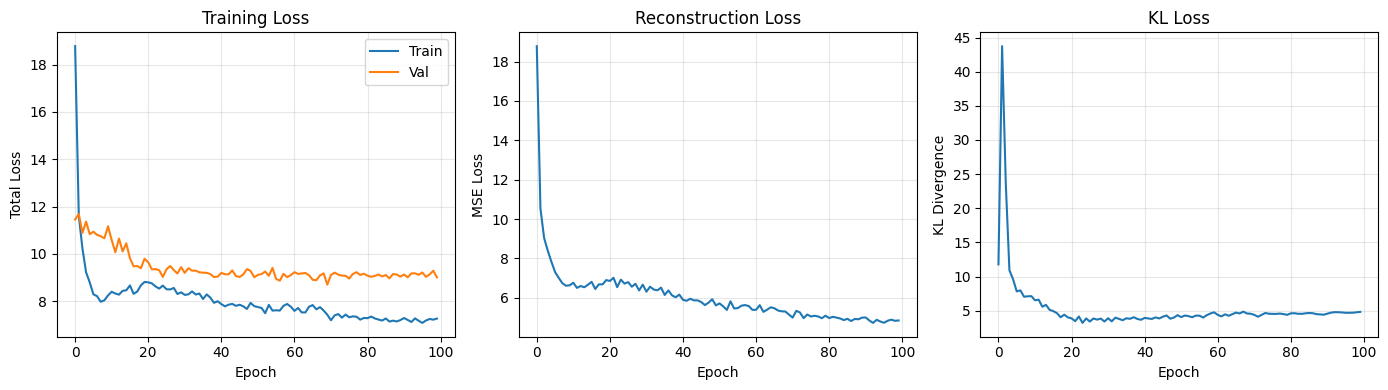

In [26]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['recon_loss'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Reconstruction Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['kl_loss'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate Reconstruction Quality


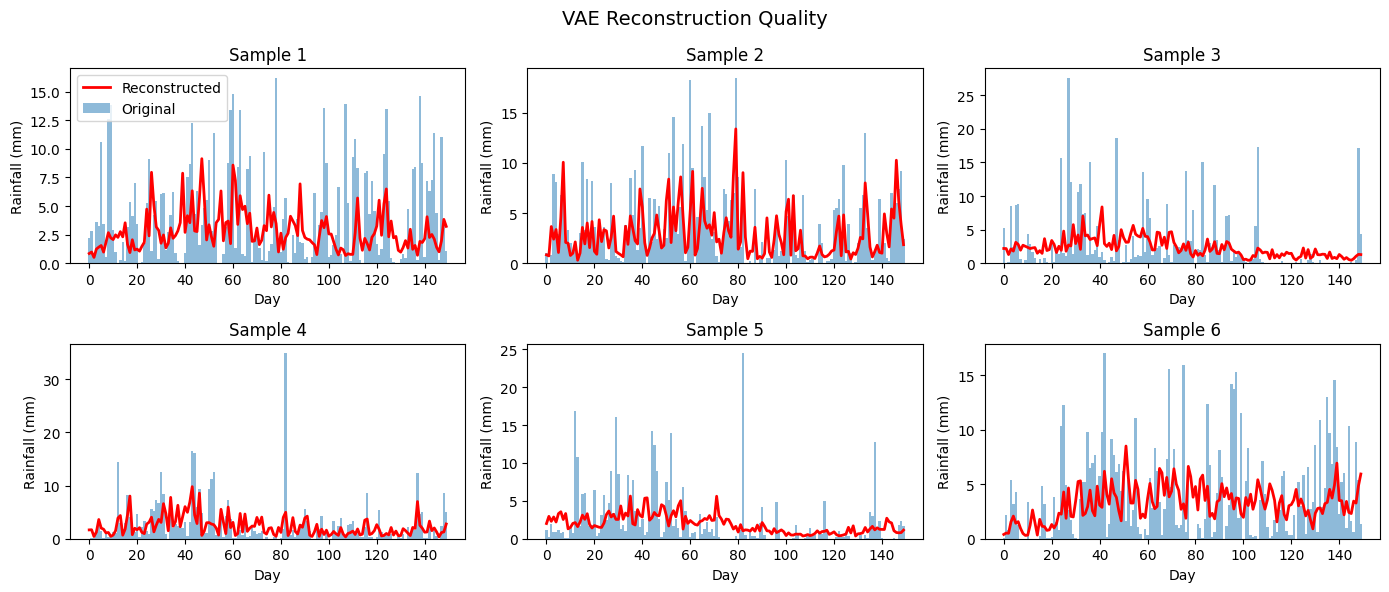

In [ ]:
model.eval()

with torch.no_grad():
    x_sample = X_val_t[:6].to(device)
    recon, _, _ = model(x_sample)

x_orig = denormalize(x_sample.cpu().numpy().squeeze())
x_recon = denormalize(recon.cpu().numpy().squeeze())

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    ax.bar(range(SEASON_LENGTH), x_orig[i], alpha=0.5, label='Original', width=1.0)
    ax.plot(x_recon[i], 'r-', linewidth=2, label='Reconstructed')
    ax.set_xlabel('Day')
    ax.set_ylabel('Rainfall (mm)')
    ax.set_title(f'Sample {i+1}')
    if i == 0:
        ax.legend()

plt.suptitle('VAE Reconstruction Quality', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

model.eval()

all_seasons_t = torch.FloatTensor(seasons_normalized).unsqueeze(1).to(device)

with torch.no_grad():
    latent_vectors = model.encode(all_seasons_t).cpu().numpy()

print(f"Latent vectors shape: {latent_vectors.shape}")

for i in range(LATENT_DIM):
    metadata[f'z{i}'] = latent_vectors[:, i]

Latent vectors shape: (185, 8)


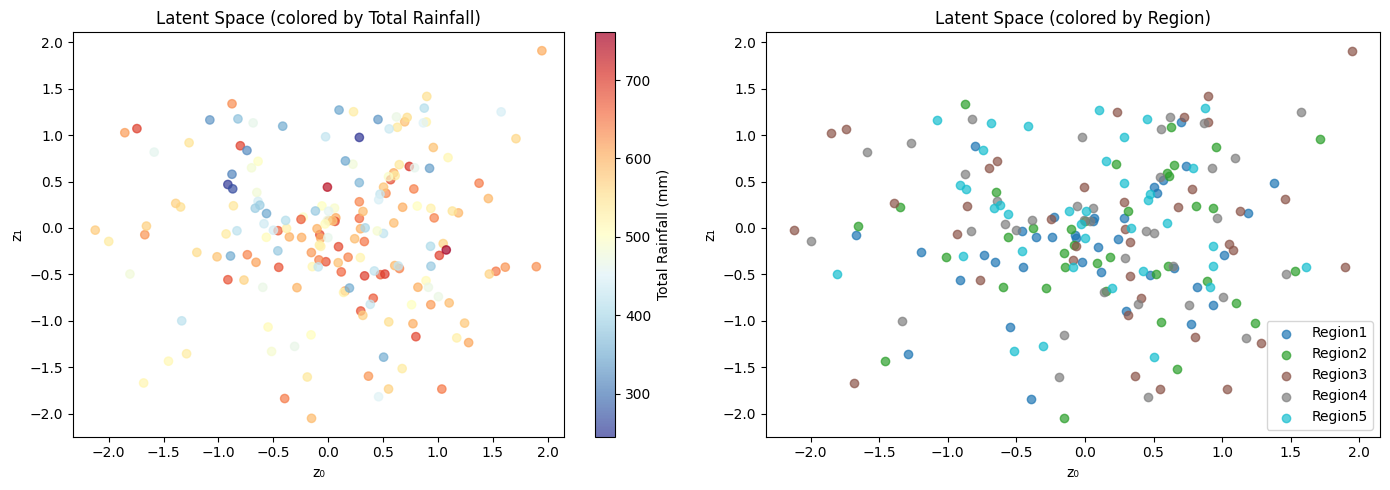

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(latent_vectors[:, 0], latent_vectors[:, 1], 
                        c=metadata['total_rainfall'], cmap='RdYlBu_r', alpha=0.7)
axes[0].set_xlabel('z₀')
axes[0].set_ylabel('z₁')
axes[0].set_title('Latent Space (colored by Total Rainfall)')
plt.colorbar(scatter1, ax=axes[0], label='Total Rainfall (mm)')

regions = metadata['region'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))
for region, color in zip(regions, colors):
    mask = metadata['region'] == region
    axes[1].scatter(latent_vectors[mask, 0], latent_vectors[mask, 1], 
                c=[color], label=region, alpha=0.7)
axes[1].set_xlabel('z₀')
axes[1].set_ylabel('z₁')
axes[1].set_title('Latent Space (colored by Region)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:

print("Correlation between latent dimensions and season properties:")
print("="*60)

correlations = []
for i in range(LATENT_DIM):
    corr_rainfall = np.corrcoef(latent_vectors[:, i], metadata['total_rainfall'])[0, 1]
    corr_rainydays = np.corrcoef(latent_vectors[:, i], metadata['rainy_days'])[0, 1]
    correlations.append({'dim': f'z{i}', 'total_rainfall': corr_rainfall, 'rainy_days': corr_rainydays})
    print(f"z{i}: Total Rainfall r={corr_rainfall:.3f}, Rainy Days r={corr_rainydays:.3f}")

corr_df = pd.DataFrame(correlations)

Correlation between latent dimensions and season properties:
z0: Total Rainfall r=0.165, Rainy Days r=0.193
z1: Total Rainfall r=-0.217, Rainy Days r=-0.190
z2: Total Rainfall r=0.317, Rainy Days r=0.289
z3: Total Rainfall r=0.206, Rainy Days r=0.294
z4: Total Rainfall r=-0.271, Rainy Days r=-0.165
z5: Total Rainfall r=0.598, Rainy Days r=0.686
z6: Total Rainfall r=0.098, Rainy Days r=-0.007
z7: Total Rainfall r=-0.025, Rainy Days r=-0.021


In [ ]:
def interpolate_seasons(model, z_start, z_end, steps=10):
    """
    Interpolate between two seasons in latent space.
    """
    alphas = np.linspace(0, 1, steps)
    interpolated = []
    
    for alpha in alphas:
        z_interp = (1 - alpha) * z_start + alpha * z_end
        z_tensor = torch.FloatTensor(z_interp).unsqueeze(0).to(device)
        
        with torch.no_grad():
            recon = model.decode(z_tensor)
        
        rainfall = denormalize(recon.cpu().numpy().squeeze())
        interpolated.append(rainfall)
    
    return np.array(interpolated), alphas


# Find driest and wettest seasons
driest_idx = metadata['total_rainfall'].argmin()
wettest_idx = metadata['total_rainfall'].argmax()

z_dry = latent_vectors[driest_idx]
z_wet = latent_vectors[wettest_idx]

print(f"Driest season: {metadata.iloc[driest_idx]['region']} {metadata.iloc[driest_idx]['year']} "
      f"({metadata.iloc[driest_idx]['total_rainfall']:.0f} mm)")
print(f"Wettest season: {metadata.iloc[wettest_idx]['region']} {metadata.iloc[wettest_idx]['year']} "
      f"({metadata.iloc[wettest_idx]['total_rainfall']:.0f} mm)")

interpolated, alphas = interpolate_seasons(model, z_dry, z_wet, steps=8)

Driest season: Region5 1999 (245 mm)
Wettest season: Region3 2012 (761 mm)


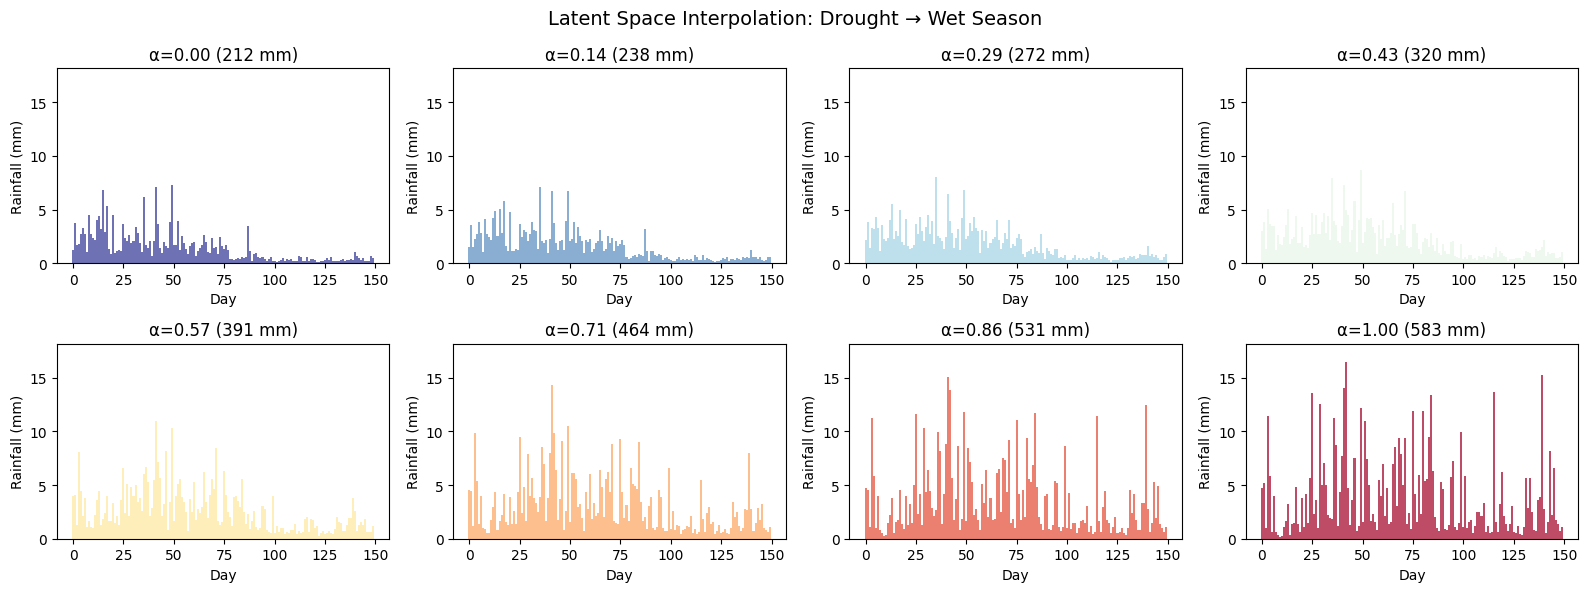


Total rainfall during interpolation:
  α=0.00: 212 mm
  α=0.14: 238 mm
  α=0.29: 272 mm
  α=0.43: 320 mm
  α=0.57: 391 mm
  α=0.71: 464 mm
  α=0.86: 531 mm
  α=1.00: 583 mm


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, (ax, alpha) in enumerate(zip(axes.flat, alphas)):
    ax.bar(range(SEASON_LENGTH), interpolated[i], alpha=0.7, width=1.0,
        color=plt.cm.RdYlBu_r(alpha))
    ax.set_xlabel('Day')
    ax.set_ylabel('Rainfall (mm)')
    total = interpolated[i].sum()
    ax.set_title(f'α={alpha:.2f} ({total:.0f} mm)')
    ax.set_ylim(0, max(interpolated.max() * 1.1, 1))

plt.suptitle('Latent Space Interpolation: Drought → Wet Season', fontsize=14)
plt.tight_layout()
plt.show()

# Print total rainfall for each step
print("\nTotal rainfall during interpolation:")
for alpha, season in zip(alphas, interpolated):
    print(f"  α={alpha:.2f}: {season.sum():.0f} mm")

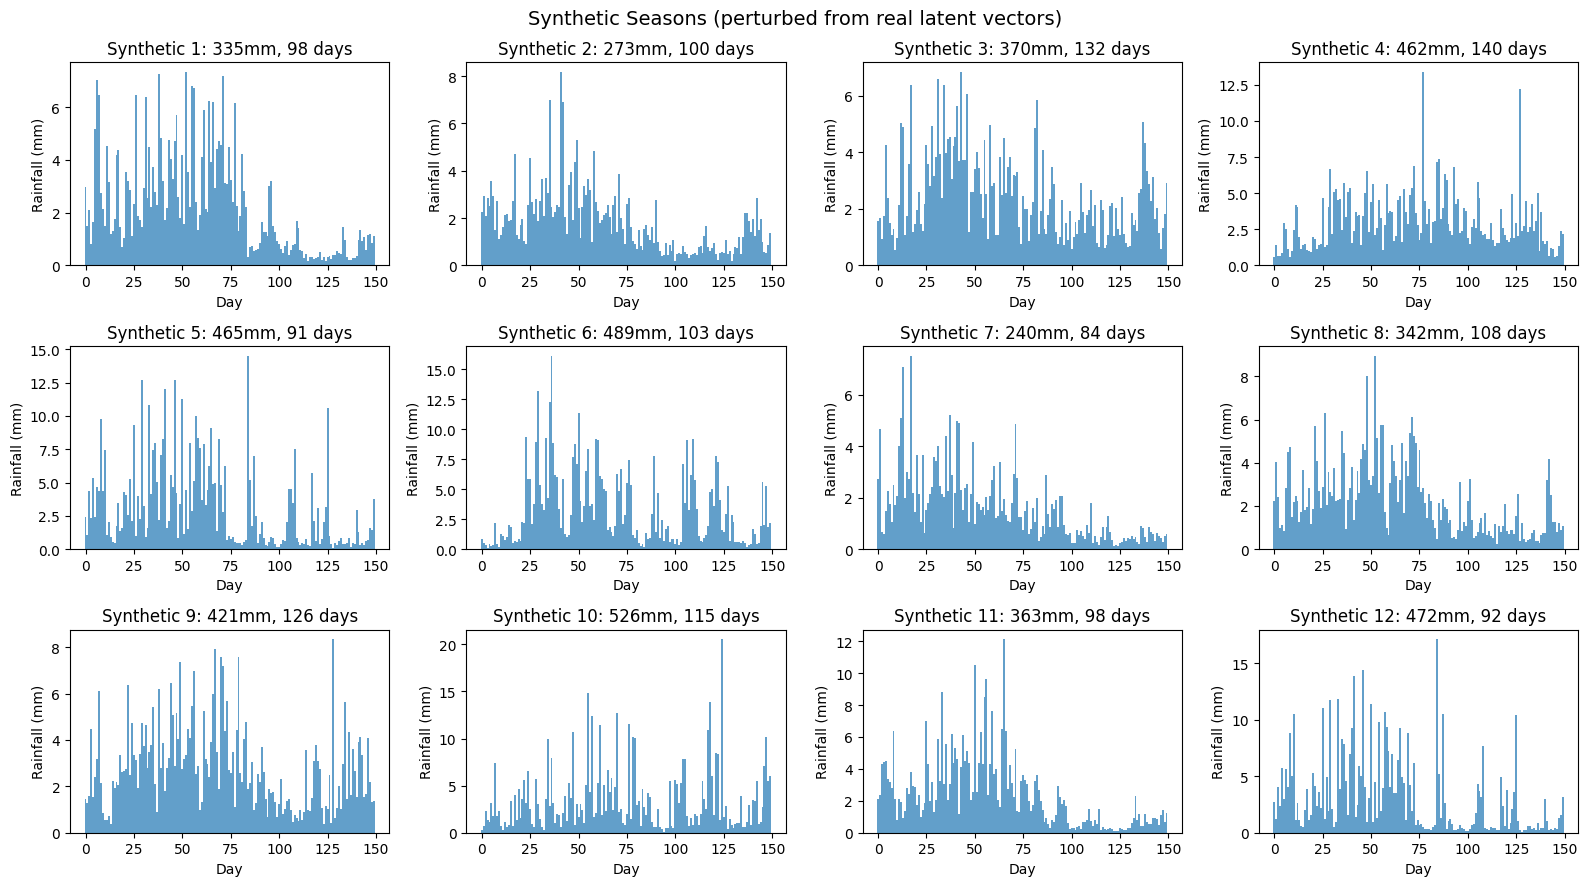

Synthetic totals: 397mm mean, 86mm std


In [ ]:
# Generate synthetic seasons by perturbing real encoded latent vectors
model.eval()

# Strategy: Randomly select real latent vectors and add small noise
# This keeps us on the learned manifold while creating variations
np.random.seed(None)  # Remove seed for variety
noise_scale = 0.3  # Controls variation amount

# Compute latent std for scaling noise
latent_std_vis = latent_vectors.std(axis=0)

# Randomly select 12 base seasons and perturb them
base_indices = np.random.choice(len(latent_vectors), size=12, replace=True)
z_perturbed = []

for idx in base_indices:
    z_base = latent_vectors[idx]
    noise = np.random.randn(LATENT_DIM) * noise_scale * latent_std_vis
    z_perturbed.append(z_base + noise)

z_perturbed = torch.tensor(np.array(z_perturbed), dtype=torch.float32)

with torch.no_grad():
    synthetic_norm = model.decode(z_perturbed.to(device)).cpu().numpy().squeeze()

synthetic_seasons = denormalize(synthetic_norm)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))

for i, ax in enumerate(axes.flat):
    ax.bar(range(SEASON_LENGTH), synthetic_seasons[i], alpha=0.7, width=1.0)
    total = synthetic_seasons[i].sum()
    rainy = (synthetic_seasons[i] > 1).sum()
    ax.set_xlabel('Day')
    ax.set_ylabel('Rainfall (mm)')
    ax.set_title(f'Synthetic {i+1}: {total:.0f}mm, {rainy} days')

plt.suptitle('Synthetic Seasons (perturbed from real latent vectors)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Synthetic totals: {synthetic_seasons.sum(axis=1).mean():.0f}mm mean, {synthetic_seasons.sum(axis=1).std():.0f}mm std")

Decoder scale correction factor: 1.318


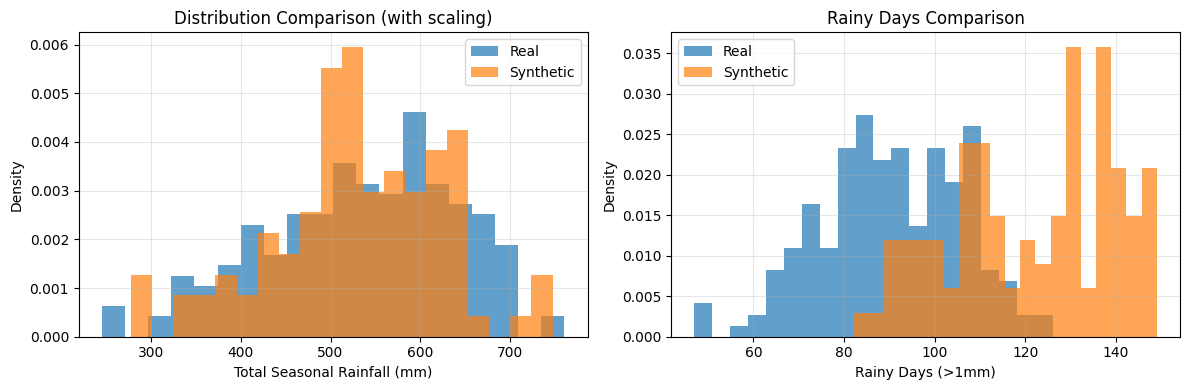

Real seasons:      Mean=534mm, Std=107mm
Synthetic seasons: Mean=531mm, Std=96mm


In [ ]:
# Compare distributions with scaling correction
# The decoder systematically underproduces due to smoothing - compute correction factor

# First, measure the encode-decode deficit on real data
with torch.no_grad():
    all_recon = model(all_seasons_t)[0].cpu().numpy().squeeze()

real_totals = seasons.sum(axis=1)
recon_totals = denormalize(all_recon).sum(axis=1)
scale_factor = real_totals.mean() / recon_totals.mean()
print(f"Decoder scale correction factor: {scale_factor:.3f}")

# Now generate with correction
n_synthetic = 100
noise_scale = 0.3

latent_std_comp = latent_vectors.std(axis=0)
base_indices = np.random.choice(len(latent_vectors), size=n_synthetic, replace=True)
z_perturbed = []
for idx in base_indices:
    noise = np.random.randn(LATENT_DIM) * noise_scale * latent_std_comp
    z_perturbed.append(latent_vectors[idx] + noise)

z_perturbed = torch.tensor(np.array(z_perturbed), dtype=torch.float32)

with torch.no_grad():
    synthetic_batch = model.decode(z_perturbed.to(device)).cpu().numpy().squeeze()

# Apply scaling correction
synthetic_rainfall = denormalize(synthetic_batch) * scale_factor
synthetic_totals = synthetic_rainfall.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(metadata['total_rainfall'], bins=20, alpha=0.7, label='Real', density=True)
axes[0].hist(synthetic_totals, bins=20, alpha=0.7, label='Synthetic', density=True)
axes[0].set_xlabel('Total Seasonal Rainfall (mm)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution Comparison (with scaling)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rainy days distribution  
synthetic_rainydays = (synthetic_rainfall > 1).sum(axis=1)
axes[1].hist(metadata['rainy_days'], bins=20, alpha=0.7, label='Real', density=True)
axes[1].hist(synthetic_rainydays, bins=20, alpha=0.7, label='Synthetic', density=True)
axes[1].set_xlabel('Rainy Days (>1mm)')
axes[1].set_ylabel('Density')
axes[1].set_title('Rainy Days Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Real seasons:      Mean={metadata['total_rainfall'].mean():.0f}mm, Std={metadata['total_rainfall'].std():.0f}mm")
print(f"Synthetic seasons: Mean={synthetic_totals.mean():.0f}mm, Std={synthetic_totals.std():.0f}mm")

## Climate Shift Simulation


Dimension most correlated with rainfall: z5 (r=0.598)


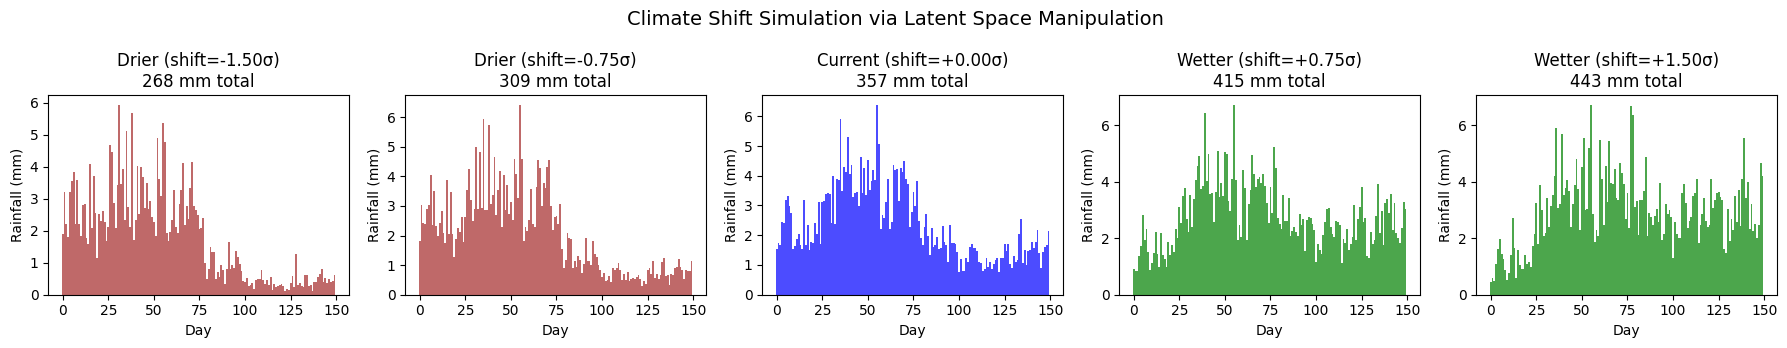

In [ ]:
# Find which latent dimension most strongly correlates with total rainfall
rainfall_dim = corr_df.loc[corr_df['total_rainfall'].abs().idxmax(), 'dim']
rainfall_dim_idx = int(rainfall_dim[1])  # e.g., 'z2' -> 2
rainfall_corr = corr_df.loc[corr_df['total_rainfall'].abs().idxmax(), 'total_rainfall']

print(f"Dimension most correlated with rainfall: {rainfall_dim} (r={rainfall_corr:.3f})")

# Generate seasons with shifted latent dimension
shift_amounts = [-1.5, -0.75, 0, 0.75, 1.5]  # Shift in std units

shifted_seasons = []
for shift in shift_amounts:
    # Start from mean latent vector
    z_mean = latent_vectors.mean(axis=0)
    z_shifted = z_mean.copy()
    
    # Apply shift to rainfall dimension
    direction = 1 if rainfall_corr > 0 else -1
    z_shifted[rainfall_dim_idx] += shift * direction
    
    z_tensor = torch.FloatTensor(z_shifted).unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon = model.decode(z_tensor)
    
    rainfall = denormalize(recon.cpu().numpy().squeeze())
    shifted_seasons.append(rainfall)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

for ax, shift, season in zip(axes, shift_amounts, shifted_seasons):
    color = 'brown' if shift < 0 else ('green' if shift > 0 else 'blue')
    ax.bar(range(SEASON_LENGTH), season, alpha=0.7, width=1.0, color=color)
    ax.set_xlabel('Day')
    ax.set_ylabel('Rainfall (mm)')
    label = 'Drier' if shift < 0 else ('Wetter' if shift > 0 else 'Current')
    ax.set_title(f'{label} (shift={shift:+.2f}σ)\n{season.sum():.0f} mm total')

plt.suptitle('Climate Shift Simulation via Latent Space Manipulation', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Save Model and Integration


In [43]:
torch.save({
    'model_state_dict': model.state_dict(),
    'latent_dim': LATENT_DIM,
    'seq_length': SEASON_LENGTH,
    'norm_params': norm_params,
    'latent_vectors': latent_vectors,
    'latent_mean': latent_vectors.mean(axis=0),
    'latent_std': latent_vectors.std(axis=0),
    'scale_factor': scale_factor,  # Correction for decoder smoothing
    'history': history
}, MODELS_DIR / 'rainfall_vae.pt')

print(f"Saved model to: {MODELS_DIR / 'rainfall_vae.pt'}")
print(f"Stored {len(latent_vectors)} latent vectors")
print(f"Scale correction factor: {scale_factor:.3f}")

Saved model to: ../models/rainfall_vae.pt
Stored 185 latent vectors
Scale correction factor: 1.318


In [ ]:
class RainfallVAEGenerator:
    """
    Wrapper for using trained VAE in RL environment.
    
    Uses perturbation-based sampling with scaling correction.
    """
    
    def __init__(self, model_path, noise_scale=0.3):
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        
        self.latent_dim = checkpoint['latent_dim']
        self.seq_length = checkpoint['seq_length']
        self.norm_min = checkpoint['norm_params']['min']
        self.norm_max = checkpoint['norm_params']['max']
        self.noise_scale = noise_scale
        self.scale_factor = checkpoint.get('scale_factor', 1.0)  # Decoder correction
        
        # Store all latent vectors for perturbation-based generation
        self.latent_vectors = checkpoint['latent_vectors']
        self.latent_std = checkpoint['latent_std']
        self.latent_mean = checkpoint['latent_mean']
        
        self.model = RainfallVAE(self.seq_length, self.latent_dim)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()
    
    def denormalize(self, x_norm):
        x_log = x_norm * (self.norm_max - self.norm_min) + self.norm_min
        return np.expm1(x_log) * self.scale_factor  # Apply correction
    
    def generate_random(self, n_seasons=1):
        """Generate random seasons by perturbing real encoded latent vectors."""
        base_indices = np.random.choice(len(self.latent_vectors), size=n_seasons, replace=True)
        z_list = []
        
        for idx in base_indices:
            noise = np.random.randn(self.latent_dim) * self.noise_scale * self.latent_std
            z_list.append(self.latent_vectors[idx] + noise)
        
        z = torch.tensor(np.array(z_list), dtype=torch.float32)
        
        with torch.no_grad():
            samples = self.model.decode(z).numpy().squeeze()
        
        return self.denormalize(samples)
    
    def generate_shifted(self, shift=0.0, dim=None):
        """Generate season with shifted climate (from mean latent)."""
        z = torch.tensor(self.latent_mean, dtype=torch.float32).unsqueeze(0)
        if dim is not None:
            z[0, dim] += shift * self.latent_std[dim]
        
        with torch.no_grad():
            sample = self.model.decode(z).numpy().squeeze()
        return self.denormalize(sample)
    
    def interpolate(self, z1, z2, alpha):
        """Interpolate between two latent vectors."""
        z = (1 - alpha) * np.array(z1) + alpha * np.array(z2)
        z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            sample = self.model.decode(z_tensor).numpy().squeeze()
        return self.denormalize(sample)


vae_gen = RainfallVAEGenerator(MODELS_DIR / 'rainfall_vae.pt')

test_seasons = vae_gen.generate_random(100)
test_totals = test_seasons.sum(axis=1)

print(f"Final synthetic seasons (with scale correction):")
print(f"  Mean: {test_totals.mean():.0f}mm (target: {metadata['total_rainfall'].mean():.0f}mm)")
print(f"  Std:  {test_totals.std():.0f}mm (target: {metadata['total_rainfall'].std():.0f}mm)")
print(f"  Scale factor: {vae_gen.scale_factor:.3f}")

Final synthetic seasons (with scale correction):
  Mean: 535mm (target: 534mm)
  Std:  102mm (target: 107mm)
  Scale factor: 1.318
